In [ ]:
!pip install pennylane


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 49.2 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [ ]:
t = np.linspace(0, 10, 300)
organoid_signal = np.sin(t) + 0.5*np.sin(3*t) + 0.2*np.random.randn(len(t))

# Normalize
signal_norm = (organoid_signal - np.min(organoid_signal)) / (
    np.max(organoid_signal) - np.min(organoid_signal)
)


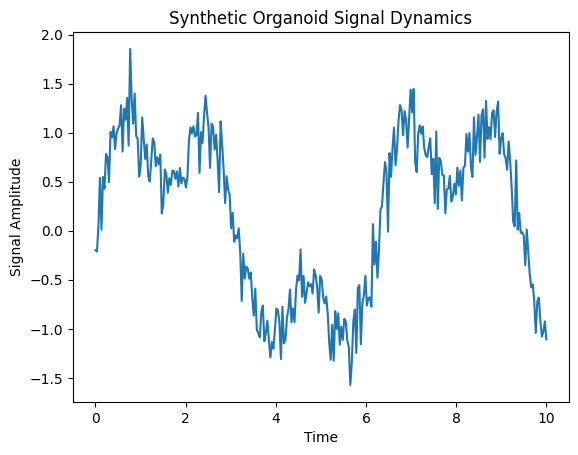

In [ ]:
plt.figure()
plt.plot(t, organoid_signal)
plt.title("Synthetic Organoid Signal Dynamics")
plt.xlabel("Time")
plt.ylabel("Signal Amplitude")
plt.show()


In [ ]:
n_qubits = 3
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_organoid_model(x):
    for i in range(n_qubits):
        qml.RY(x*(i+1), wires=i)
        qml.RZ(x, wires=i)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [ ]:
quantum_outputs = np.array(
    [quantum_organoid_model(x) for x in signal_norm]
)


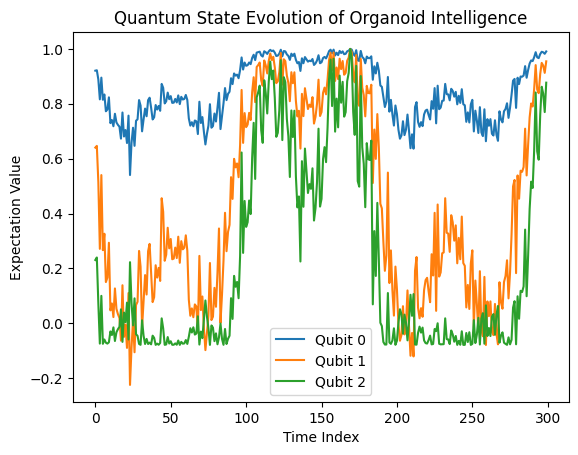

In [ ]:
plt.figure()
for i in range(n_qubits):
    plt.plot(quantum_outputs[:, i], label=f"Qubit {i}")
plt.title("Quantum State Evolution of Organoid Intelligence")
plt.xlabel("Time Index")
plt.ylabel("Expectation Value")
plt.legend()
plt.show()


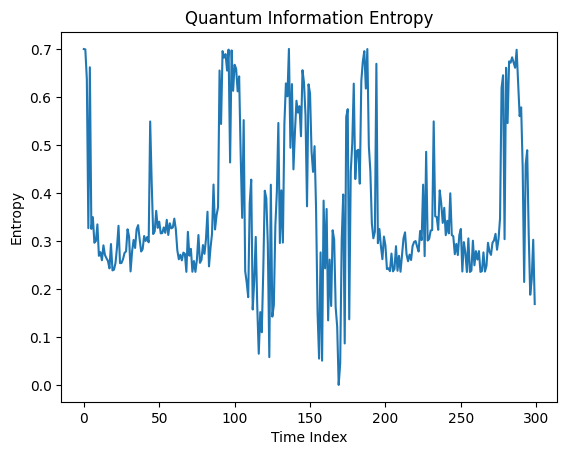

In [ ]:
entropy = -np.sum(
    quantum_outputs * np.log(np.abs(quantum_outputs) + 1e-9),
    axis=1
)

plt.figure()
plt.plot(entropy)
plt.title("Quantum Information Entropy")
plt.xlabel("Time Index")
plt.ylabel("Entropy")
plt.show()


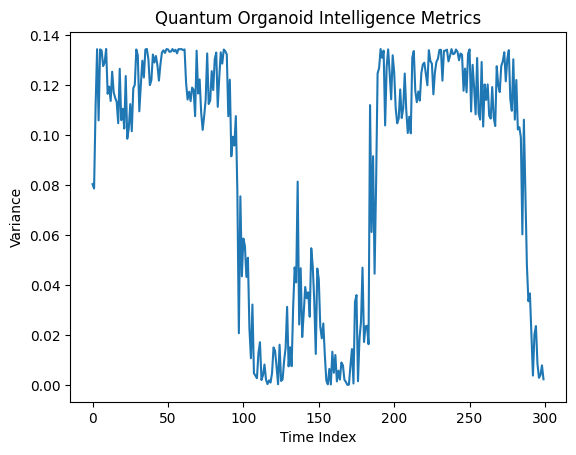

In [ ]:
intelligence_metric = np.var(quantum_outputs, axis=1)

plt.figure()
plt.plot(intelligence_metric)
plt.title("Quantum Organoid Intelligence Metrics")
plt.xlabel("Time Index")
plt.ylabel("Variance")
plt.show()


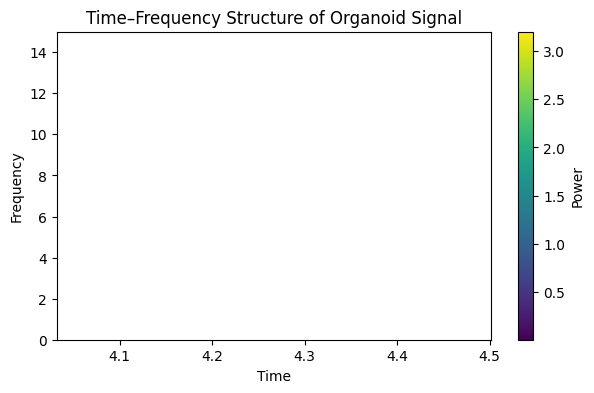

In [ ]:
from scipy.signal import spectrogram

f, t_spec, Sxx = spectrogram(organoid_signal, fs=30)

plt.figure(figsize=(7,4))
plt.pcolormesh(t_spec, f, Sxx, shading='gouraud')
plt.ylabel('Frequency')
plt.xlabel('Time')
plt.title("Time–Frequency Structure of Organoid Signal")
plt.colorbar(label="Power")
plt.show()


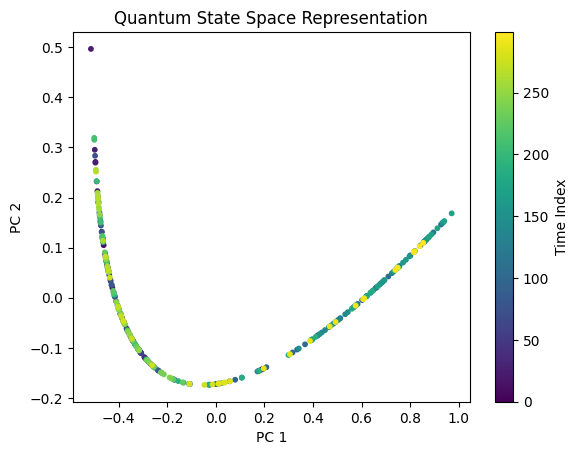

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
quantum_pca = pca.fit_transform(quantum_outputs)

plt.figure()
plt.scatter(quantum_pca[:,0], quantum_pca[:,1],
            c=np.arange(len(quantum_pca)), cmap='viridis', s=10)
plt.colorbar(label="Time Index")
plt.title("Quantum State Space Representation")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


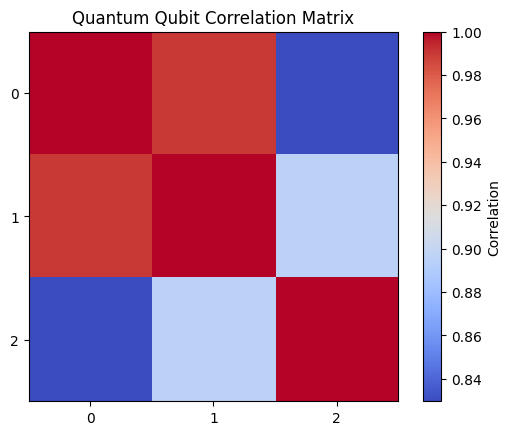

In [ ]:
correlation_matrix = np.corrcoef(quantum_outputs.T)

plt.figure()
plt.imshow(correlation_matrix, cmap='coolwarm')
plt.colorbar(label="Correlation")
plt.xticks(range(n_qubits))
plt.yticks(range(n_qubits))
plt.title("Quantum Qubit Correlation Matrix")
plt.show()


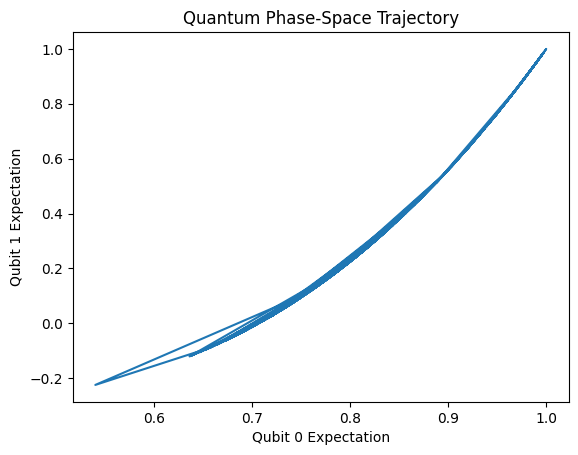

In [ ]:
plt.figure()
plt.plot(quantum_outputs[:,0], quantum_outputs[:,1])
plt.xlabel("Qubit 0 Expectation")
plt.ylabel("Qubit 1 Expectation")
plt.title("Quantum Phase-Space Trajectory")
plt.show()


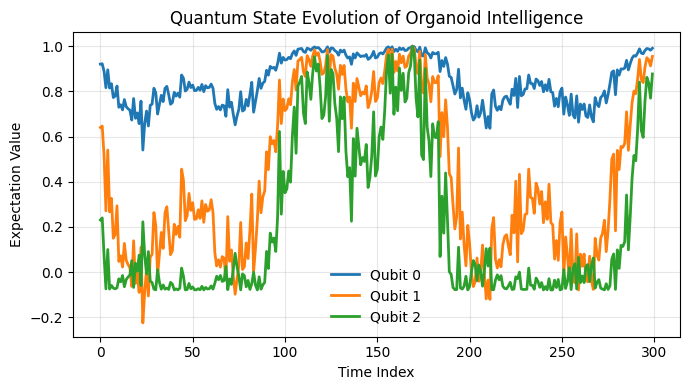

In [ ]:
plt.figure(figsize=(7,4))

for i in range(n_qubits):
    plt.plot(
        quantum_outputs[:, i],
        linewidth=2,
        label=f"Qubit {i}"
    )

plt.title("Quantum State Evolution of Organoid Intelligence")
plt.xlabel("Time Index")
plt.ylabel("Expectation Value")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


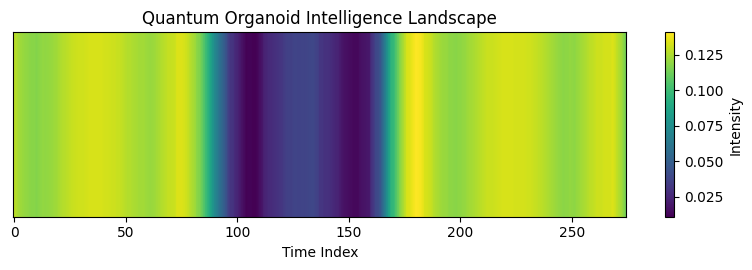

In [ ]:
window = 25
intelligence_metric = [
    np.var(quantum_outputs[i:i+window])
    for i in range(len(quantum_outputs)-window)
]

plt.figure(figsize=(8,2.8))
plt.imshow(
    np.array(intelligence_metric).reshape(1, -1),
    aspect="auto",
    cmap="viridis"
)
plt.colorbar(label="Intensity")
plt.yticks([])
plt.xlabel("Time Index")
plt.title("Quantum Organoid Intelligence Landscape")
plt.tight_layout()
plt.show()


In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy


In [ ]:
T = 300
time = np.arange(T)

signal = (
    0.6 * np.sin(0.04 * time) +
    0.3 * np.sin(0.1 * time) +
    0.1 * np.random.normal(size=T)
)

signal = (signal - np.min(signal)) / (np.max(signal) - np.min(signal))


In [ ]:
n_qubits = 3
dev = qml.device("default.qubit", wires=n_qubits)


In [ ]:
@qml.qnode(dev)
def quantum_circuit(x):
    for i in range(n_qubits):
        qml.RY(x, wires=i)

    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [ ]:
expectations = []

for t in range(T):
    exp_vals = quantum_circuit(signal[t])
    expectations.append(exp_vals)

expectations = np.array(expectations).T


In [ ]:
print(expectations.shape)


(3, 300)


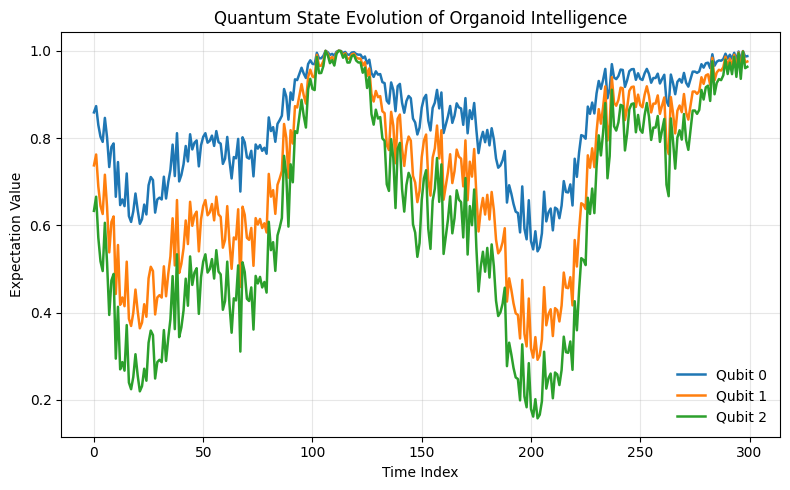

In [ ]:
plt.figure(figsize=(8,5))
for i in range(n_qubits):
    plt.plot(time, expectations[i], label=f"Qubit {i}", linewidth=1.8)

plt.xlabel("Time Index")
plt.ylabel("Expectation Value")
plt.title("Quantum State Evolution of Organoid Intelligence")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


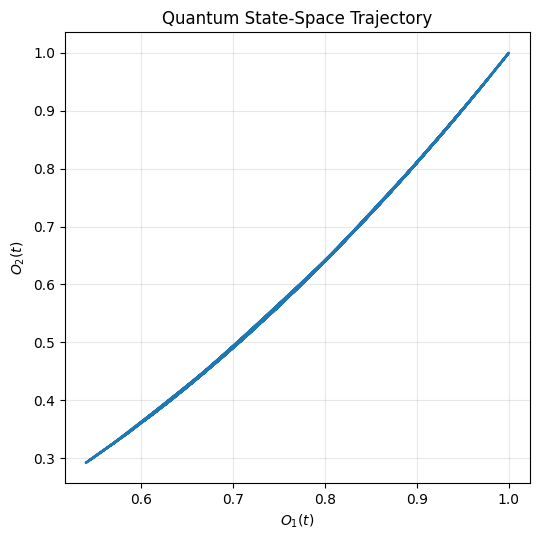

In [ ]:
plt.figure(figsize=(5.5,5.5))
plt.plot(expectations[0], expectations[1], linewidth=1.8)

plt.xlabel(r"$O_1(t)$")
plt.ylabel(r"$O_2(t)$")
plt.title("Quantum State-Space Trajectory")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


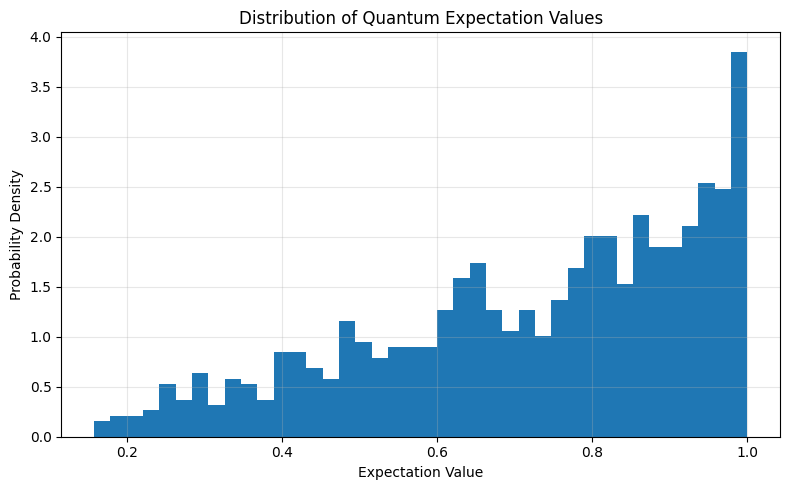

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(expectations.flatten(), bins=40, density=True)

plt.xlabel("Expectation Value")
plt.ylabel("Probability Density")
plt.title("Distribution of Quantum Expectation Values")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


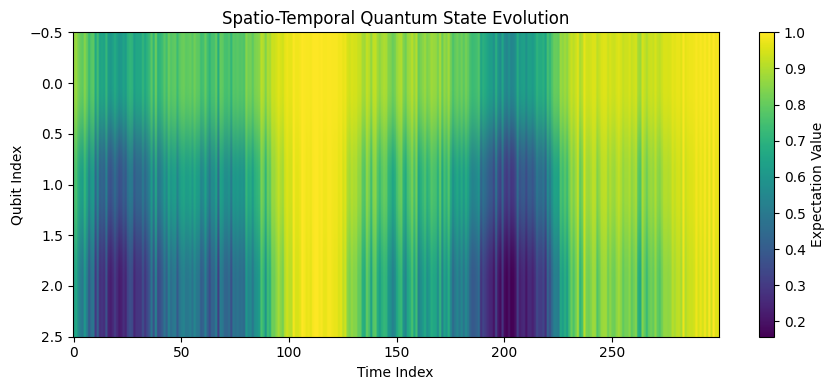

In [ ]:
plt.figure(figsize=(9,4))
plt.imshow(expectations, aspect='auto')

plt.colorbar(label="Expectation Value")
plt.xlabel("Time Index")
plt.ylabel("Qubit Index")
plt.title("Spatio-Temporal Quantum State Evolution")
plt.tight_layout()
plt.show()


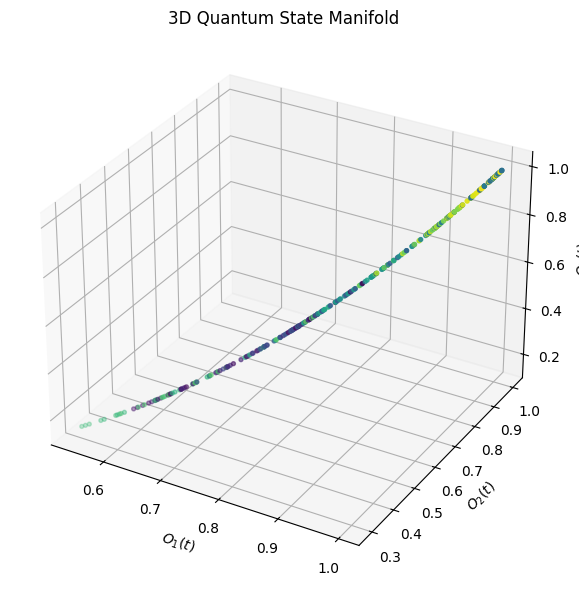

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    expectations[0],
    expectations[1],
    expectations[2],
    c=time,
    cmap='viridis',
    s=8
)

ax.set_xlabel(r"$O_1(t)$")
ax.set_ylabel(r"$O_2(t)$")
ax.set_zlabel(r"$O_3(t)$")
ax.set_title("3D Quantum State Manifold")

plt.tight_layout()
plt.show()


In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# PARAMETERS
# -----------------------------
T = 300
time = np.arange(T)
n_qubits = 3

# -----------------------------
# SYNTHETIC SIGNAL
# -----------------------------
signal = (
    0.6 * np.sin(0.04 * time) +
    0.3 * np.sin(0.1 * time) +
    0.1 * np.random.normal(size=T)
)
signal = (signal - signal.min()) / (signal.max() - signal.min())

# -----------------------------
# QUANTUM DEVICE
# -----------------------------
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x):
    for i in range(n_qubits):
        qml.RY(x, wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# -----------------------------
# RUN CIRCUIT
# -----------------------------
expectations = []
for t in range(T):
    expectations.append(circuit(signal[t]))

expectations = np.array(expectations).T  # shape (3, T)

# -----------------------------
# ENTROPY VALUES (THIS WAS MISSING)
# -----------------------------
entropy_values = []
for t in range(T):
    p = np.abs(expectations[:, t])
    p = p / np.sum(p)
    entropy_values.append(entropy(p))

entropy_values = np.array(entropy_values)


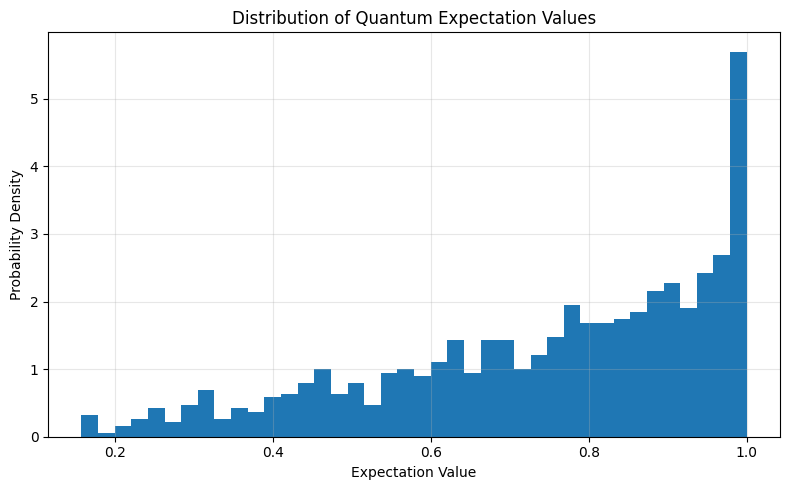

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(expectations.flatten(), bins=40, density=True)
plt.xlabel("Expectation Value")
plt.ylabel("Probability Density")
plt.title("Distribution of Quantum Expectation Values")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


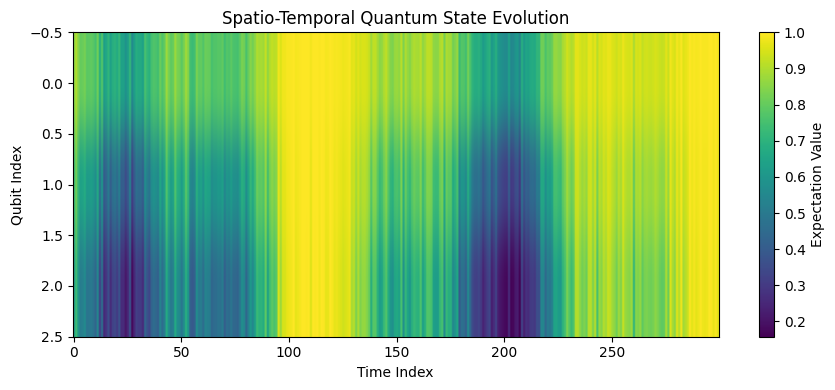

In [ ]:
plt.figure(figsize=(9,4))
plt.imshow(expectations, aspect='auto')
plt.colorbar(label="Expectation Value")
plt.xlabel("Time Index")
plt.ylabel("Qubit Index")
plt.title("Spatio-Temporal Quantum State Evolution")
plt.tight_layout()
plt.show()


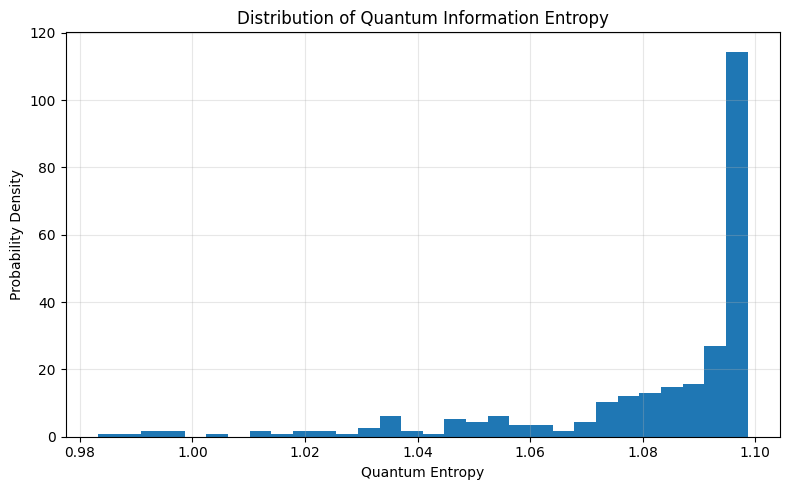

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(entropy_values, bins=30, density=True)
plt.xlabel("Quantum Entropy")
plt.ylabel("Probability Density")
plt.title("Distribution of Quantum Information Entropy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


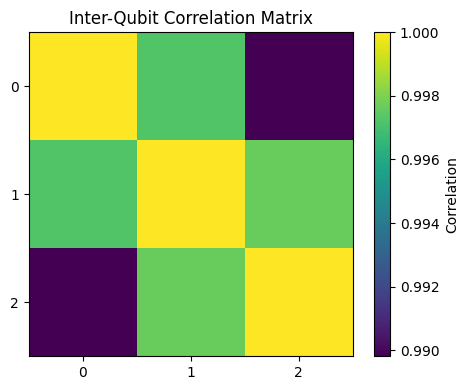

In [ ]:
corr = np.corrcoef(expectations)
plt.figure(figsize=(5,4))
plt.imshow(corr)
plt.colorbar(label="Correlation")
plt.xticks(range(n_qubits))
plt.yticks(range(n_qubits))
plt.title("Inter-Qubit Correlation Matrix")
plt.tight_layout()
plt.show()


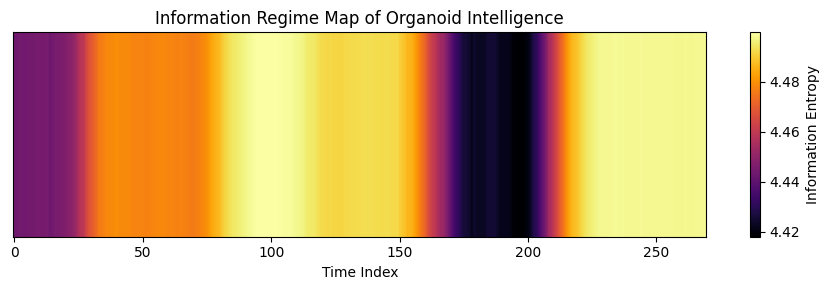

In [ ]:
window = 30
entropy_map = []

for t in range(window, T):
    segment = expectations[:, t-window:t]
    p = np.abs(segment)
    p = p / np.sum(p)
    entropy_map.append(entropy(p.flatten()))

entropy_map = np.array(entropy_map)

plt.figure(figsize=(9,3))
plt.imshow(entropy_map.reshape(1, -1), aspect='auto', cmap='inferno')
plt.colorbar(label="Information Entropy")
plt.yticks([])
plt.xlabel("Time Index")
plt.title("Information Regime Map of Organoid Intelligence")
plt.tight_layout()
plt.show()


In [ ]:
stability = np.mean(np.abs(expectations), axis=1)
adaptability = np.var(expectations, axis=1)


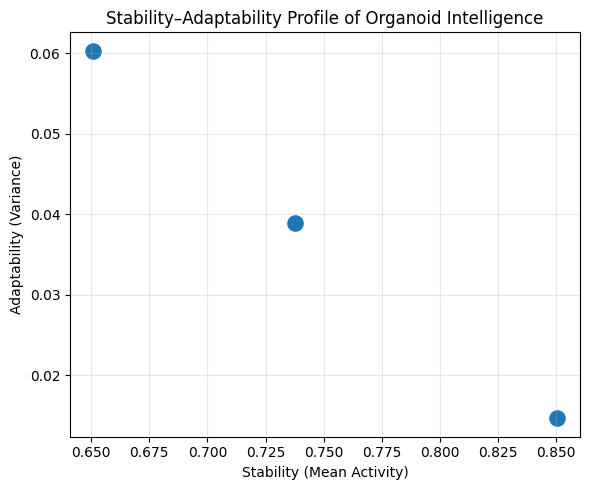

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(stability, adaptability, s=120)

plt.xlabel("Stability (Mean Activity)")
plt.ylabel("Adaptability (Variance)")
plt.title("Stability–Adaptability Profile of Organoid Intelligence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


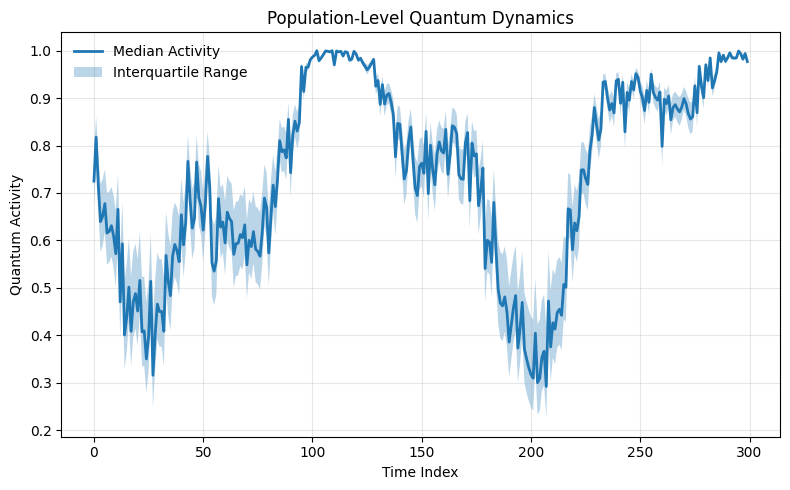

In [ ]:
median = np.median(expectations, axis=0)
q25 = np.percentile(expectations, 25, axis=0)
q75 = np.percentile(expectations, 75, axis=0)

plt.figure(figsize=(8,5))
plt.plot(time, median, label="Median Activity", linewidth=2)
plt.fill_between(time, q25, q75, alpha=0.3, label="Interquartile Range")

plt.xlabel("Time Index")
plt.ylabel("Quantum Activity")
plt.title("Population-Level Quantum Dynamics")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


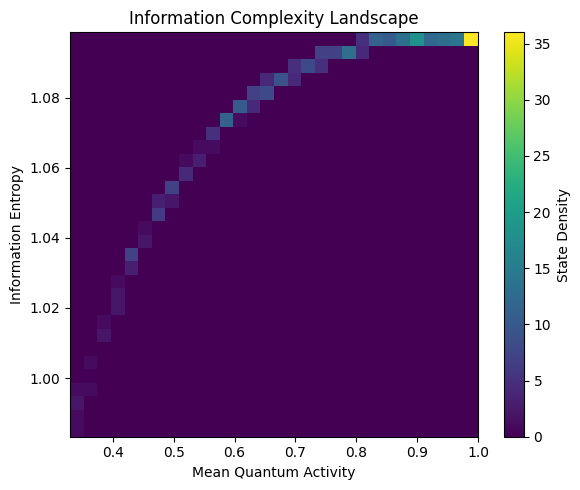

In [ ]:
activity = np.mean(np.abs(expectations), axis=0)
complexity = entropy_values

plt.figure(figsize=(6,5))
plt.hist2d(activity, complexity, bins=30, cmap='viridis')
plt.colorbar(label="State Density")

plt.xlabel("Mean Quantum Activity")
plt.ylabel("Information Entropy")
plt.title("Information Complexity Landscape")
plt.tight_layout()
plt.show()


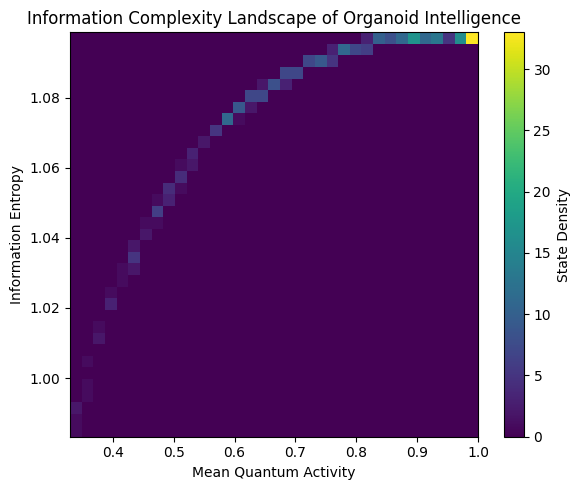

In [ ]:
# Mean quantum activity across qubits
activity = np.mean(np.abs(expectations), axis=0)

# Information complexity landscape
plt.figure(figsize=(6,5))
plt.hist2d(activity, entropy_values, bins=35, cmap='viridis')
plt.colorbar(label="State Density")

plt.xlabel("Mean Quantum Activity")
plt.ylabel("Information Entropy")
plt.title("Information Complexity Landscape of Organoid Intelligence")

plt.tight_layout()
plt.show()
